# Reliability Under Distribution Shift: Calibration and Abstention
Project mentor: CS 475/675 Anqi Liu

Team member: Justin Wang, Kayleigh Huk, Jonathan Nichols

Repository: `ml_reliability_under_shift`

Repository Link: https://github.com/wubis/ml_reliability_under_shift

Notebook Link (within repository): https://github.com/wubis/ml_reliability_under_shift/tree/main/notebooks

# Outline and Deliverables

## Must Accomplish: Completed

1. Train baseline classifiers for the Breast Cancer Wisconsin diagnostic task. We completed this with a cross-validated logistic regression model and a small feedforward neural network.
2. Evaluate calibration and reliability on clean data. We completed this with log loss, Brier score, expected calibration error, reliability diagrams, and post-hoc temperature scaling.
3. Evaluate behavior under distribution shift. We completed this with matched synthetic covariate shifts across multiple severities and perturbation replicates.

## Expect To Accomplish: Completed

1. Apply abstention on top of calibrated probabilities. We completed this with calibrated threshold abstention and calibrated split conformal abstention.
2. Compare reliability/abstention behavior across model classes. We completed this for both logistic regression and the neural network.
3. Use class-sensitive metrics. We added malignant recall, benign recall, false-benign rate, balanced accuracy, and macro metrics.

## Would Like To Accomplish: Partially Completed

1. Learned abstention model: completed as a lightweight learned correctness predictor over calibrated uncertainty features. Its shifted coverage is lower than its calibration target, so we treat it as an informative stretch result rather than the cleanest operating point.
2. Real external-shift dataset: not completed. We instead used matched synthetic covariate shifts so clean-vs-shifted comparisons are controlled and reproducible.
3. Random forest implementation: not completed, we decided to simplify with only a two model comparison.

## Additional Work

We added class-sensitive evaluation for malignant and benign recall. This matters because overall accuracy can look high even when the model makes the most costly error: predicting benign for a malignant case.

# Preliminaries

We studied how binary classifiers behave when test-time covariates shift away from the clean training distribution. The concrete task is breast-cancer diagnosis from continuous tumor measurements. In this setting reliability is not just whether the top-1 prediction is correct; it is also whether the model's confidence remains meaningful when measurements change in a plausible way.

This project connects to several course themes: proper losses and probabilistic prediction, calibration, distribution shift, model selection, and uncertainty-aware decision rules. The ethical stakes are also clear. A model that is confidently wrong under a new hospital, scanner, staining protocol, or measurement process could cause harm if used without human review. Abstention is one way to make the model less brittle: when uncertainty is high, the system can defer instead of forcing a diagnosis.

## Dataset

We used the `sklearn.datasets.load_breast_cancer` dataset, a cleaned version of the Breast Cancer Wisconsin diagnostic data. It contains 569 examples, 30 continuous features computed from digitized cell nuclei, and a binary label where `0` is malignant and `1` is benign. The dataset is small but useful for this project because the features are interpretable and the task is sensitive to class-specific errors.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.datasets import load_breast_cancer

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

ARTIFACT_DIR = REPO_ROOT / "artifacts" / "final_report"
TABLE_DIR = ARTIFACT_DIR / "tables"
FIGURE_DIR = ARTIFACT_DIR / "figures"

data = load_breast_cancer()
print(f"n_examples = {data.data.shape[0]}")
print(f"n_features = {data.data.shape[1]}")
print(dict(zip(data.target_names, pd.Series(data.target).value_counts().sort_index())))
pd.DataFrame(data.data[:3], columns=data.feature_names)

n_examples = 569
n_features = 30
{np.str_('malignant'): 212, np.str_('benign'): 357}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


## Pre-processing

All features are continuous. We used a stratified 60/20/20 split into train, calibration, and test sets. The calibration split is held out from training so temperature scaling and conformal thresholds do not reuse training examples. We fit a `StandardScaler` only on the training split and applied it to calibration, clean test, and shifted test copies. This avoids leaking test-set statistics into the training pipeline.

In [2]:
from src.evaluation.experiment_pipeline import prepare_breast_cancer_split

split = prepare_breast_cancer_split(random_state=42)
examples = pd.DataFrame(split["X_test_raw"][:3], columns=data.feature_names)
scaled_examples = pd.DataFrame(split["X_test"][:3], columns=data.feature_names)
display(examples)
display(scaled_examples)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050
1,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
2,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.556779,2.119783,1.721872,1.590546,-0.293435,1.842982,1.022815,1.634623,0.291899,-0.125265,...,1.818349,1.658184,2.103633,1.840506,-0.196487,1.635910,0.632589,1.157370,-0.152595,0.847523
1,-0.818021,-0.566916,-0.854560,-0.752890,-1.114652,-1.256746,-0.944674,-0.901262,-1.069237,-0.239451,...,-0.917270,-0.802041,-0.947072,-0.784467,-1.303695,-1.200465,-1.069580,-1.100828,-0.821027,-0.738536
2,-0.059326,1.173357,0.037580,-0.143409,1.454152,1.137995,0.512756,0.455827,1.653034,1.240896,...,-0.031314,1.145509,-0.020887,-0.144489,2.066453,0.814602,0.242163,0.540135,1.127415,1.799052


# Models and Evaluation

## Experimental Setup

The two base classifiers are logistic regression and a feedforward neural network. Logistic regression uses cross-validation over L2 regularization strength with log-loss scoring. The neural network is a compact multilayer perceptron trained with binary cross-entropy with logits.

We evaluate clean and shifted performance with accuracy, balanced accuracy, malignant recall, benign recall, ROC AUC, log loss, Brier score, and expected calibration error. We report raw confidence behavior and temperature-scaled ECE. For abstention we use selective risk: the error rate among retained, non-abstained predictions. To match our proposal, the main abstention results are applied after temperature scaling, so the abstention rule sees calibrated probabilities rather than raw model scores.

In [3]:
clean_metrics = pd.read_csv(TABLE_DIR / "clean_metrics.csv")
shift_summary = pd.read_csv(TABLE_DIR / "shift_severity_summary.csv")
abstention_summary = pd.read_csv(TABLE_DIR / "abstention_summary.csv")

clean_metrics.round(4)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,malignant_recall,benign_recall,false_benign_rate,false_malignant_rate,roc_auc,ece,brier,avg_confidence,log_loss,temp_ece
0,logistic,0.9825,0.9812,0.9812,0.9812,0.9812,0.9762,0.9861,0.0238,0.0139,0.9950,0.0362,0.0484,0.9463,0.0866,0.0246
1,neural_net,0.9561,0.9603,0.9483,0.9603,0.9535,0.9762,0.9444,0.0238,0.0556,0.9934,0.0245,0.0508,0.9785,0.1033,0.0217


## Baselines

Logistic regression is a strong baseline here because the dataset has only 30 standardized continuous features and the classes are close to linearly separable. The neural network baseline asks whether a more flexible non-linear classifier improves reliability, not just accuracy. On clean data, logistic regression performs best on accuracy and balanced accuracy, while the neural network has slightly lower clean ECE.

In [4]:
display(clean_metrics[[
    "model", "accuracy", "balanced_accuracy", "malignant_recall",
    "benign_recall", "roc_auc", "ece", "temp_ece", "brier", "log_loss"
]].round(4))
display(pd.read_csv(TABLE_DIR / "clean_confusion_matrices.csv"))

,model,accuracy,balanced_accuracy,malignant_recall,benign_recall,roc_auc,ece,temp_ece,brier,log_loss
0,logistic,0.9825,0.9812,0.9762,0.9861,0.9950,0.0362,0.0246,0.0484,0.0866
1,neural_net,0.9561,0.9603,0.9762,0.9444,0.9934,0.0245,0.0217,0.0508,0.1033


,model,tn_malignant,false_benign,false_malignant,tp_benign
0,logistic,41,1,1,71
1,neural_net,41,1,4,68


## Methods

The shift generator creates matched shifted copies of the same clean test examples. That means any clean-vs-shifted difference is caused by perturbed features rather than by a different sample composition. The perturbations target features we identified as plausible sources of acquisition or population shift, especially malignant examples' texture and worst-case geometric measurements, plus small background jitter on other features.

Temperature scaling is fit on calibration logits to test whether simple post-hoc calibration improves confidence estimates. Abstention is then evaluated in three forms on top of those calibrated probabilities: confidence thresholding at 0.8, split conformal prediction sets with alpha = 0.1 fit on calibrated calibration probabilities, and a learned abstainer trained on calibration-set uncertainty features to predict whether the base classifier will be correct. For transparency, the artifact table also includes raw-probability abstention variants, but the proposal-aligned method is calibrated + abstention. The conformal method abstains when its prediction set is empty or has more than one label.

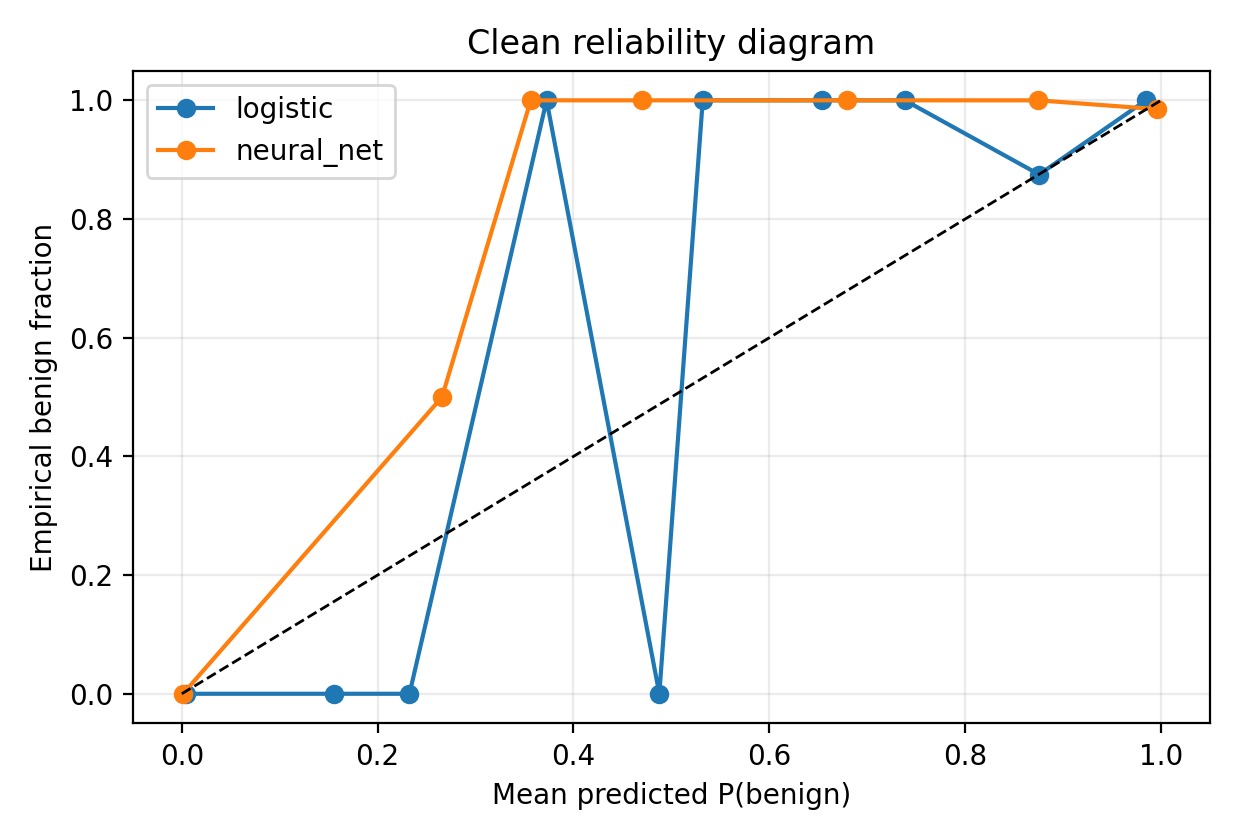

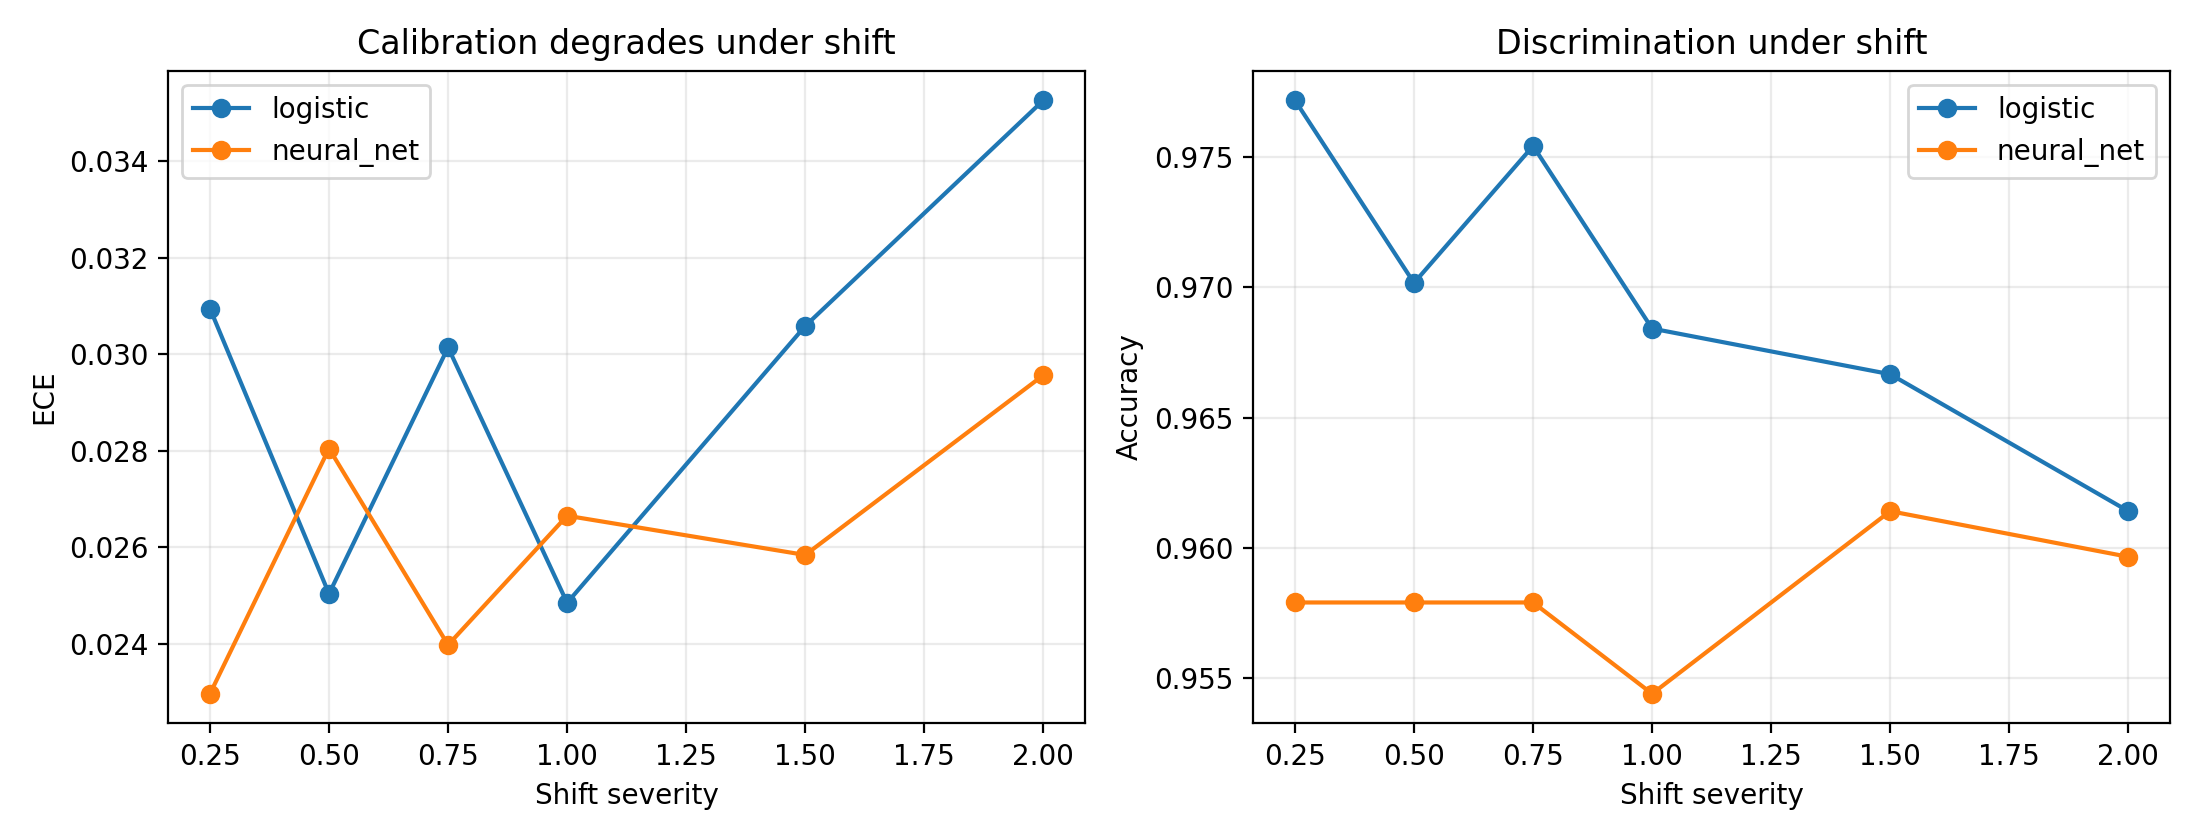

In [5]:
display(Image(filename=str(FIGURE_DIR / "clean_reliability.png")))
display(Image(filename=str(FIGURE_DIR / "shift_sweep.png")))

# Results

The shift results do not show a dramatic accuracy collapse, which is an important finding rather than a failure. The test set is small and the shift is matched, so the decision boundary often remains correct. However, reliability metrics still move in the expected direction. For logistic regression, accuracy drops from 0.9825 clean to 0.9614 at severity 2.0, while Brier score increases from 0.0484 to 0.0524. For the neural net, accuracy remains roughly stable, but Brier score increases from 0.0508 to 0.0584 and log loss increases from 0.1033 to 0.1091 at severity 2.0.

Temperature scaling helps on clean data and often under shift, but it is not a cure-all. This matches the core lesson: calibration is distribution-dependent. A scalar temperature learned on clean calibration examples cannot fully repair a shifted test distribution.

In [6]:
display(shift_summary[[
    "model", "severity", "accuracy", "accuracy_std", "balanced_accuracy",
    "malignant_recall", "ece", "temp_ece", "brier", "log_loss",
    "delta_accuracy", "delta_brier", "delta_log_loss"
]].round(4))

,model,severity,accuracy,accuracy_std,balanced_accuracy,malignant_recall,ece,temp_ece,brier,log_loss,delta_accuracy,delta_brier,delta_log_loss
0,logistic,0.25,0.9772,0.0048,0.9740,0.9619,0.0309,0.0245,0.0487,0.0872,-0.0053,0.0003,0.0006
1,logistic,0.50,0.9702,0.0048,0.9665,0.9524,0.0250,0.0188,0.0491,0.0875,-0.0123,0.0007,0.0008
2,logistic,0.75,0.9754,0.0073,0.9736,0.9667,0.0301,0.0234,0.0488,0.0875,-0.0070,0.0004,0.0009
3,logistic,1.00,0.9684,0.0048,0.9671,0.9619,0.0248,0.0168,0.0515,0.0907,-0.0140,0.0031,0.0040
4,logistic,1.50,0.9667,0.0114,0.9637,0.9524,0.0306,0.0222,0.0533,0.0934,-0.0158,0.0049,0.0068
5,logistic,2.00,0.9614,0.0048,0.9595,0.9524,0.0353,0.0230,0.0524,0.0908,-0.0211,0.0040,0.0041
6,neural_net,0.25,0.9579,0.0039,0.9617,0.9762,0.0230,0.0187,0.0508,0.1038,0.0018,-0.0000,0.0005
7,neural_net,0.50,0.9579,0.0073,0.9607,0.9714,0.0280,0.0220,0.0520,0.1043,0.0018,0.0011,0.0010
8,neural_net,0.75,0.9579,0.0073,0.9607,0.9714,0.0240,0.0207,0.0519,0.1057,0.0018,0.0011,0.0024
9,neural_net,1.00,0.9544,0.0073,0.9579,0.9714,0.0266,0.0216,0.0564,0.1103,-0.0018,0.0056,0.0070


## Abstention Results

Abstention is the clearest robustness result, and it is now applied on top of calibration as intended in the proposal. At representative severity 1.5, logistic regression's un-abstained selective risk is 0.0351. Calibrated threshold abstention reduces that to 0.0093 while retaining 94.74% of examples. Calibrated split conformal abstention gives similar risk, 0.0099, while retaining 88.60%. The calibrated learned abstainer drives logistic selective risk to 0.0000, but with lower shifted coverage of 80.70%, so it is best interpreted as an aggressive stretch method rather than the cleanest operating point.

For the neural network, calibrated conformal abstention reduces selective risk from 0.0263 to 0.0096 at 91.23% coverage. The calibrated learned abstainer reaches similar selective risk, 0.0105, at 83.33% coverage. This supports the project hypothesis: calibrated selective prediction can preserve reliability on retained cases, at the cost of coverage. It also shows a limitation of learned abstention under shift: a target coverage learned on calibration data may not transfer exactly to shifted data.

,model,probability_source,method,severity,coverage,abstention_rate,selective_risk,retained_count,malignant_recall_retained,benign_recall_retained
1,logistic,calibrated,none,1.5,1.0000,0.0000,0.0351,114.0,0.9524,0.9722
3,logistic,calibrated,threshold_0.8,1.5,0.9474,0.0526,0.0093,108.0,0.9756,1.0000
5,logistic,calibrated,split_conformal_alpha_0.1,1.5,0.8860,0.1140,0.0099,101.0,0.9744,1.0000
7,logistic,calibrated,learned_target_coverage_0.9,1.5,0.8070,0.1930,0.0000,92.0,1.0000,1.0000
9,neural_net,calibrated,none,1.5,1.0000,0.0000,0.0263,114.0,0.9524,0.9861
11,neural_net,calibrated,threshold_0.8,1.5,0.9474,0.0526,0.0185,108.0,0.9756,0.9851
13,neural_net,calibrated,split_conformal_alpha_0.1,1.5,0.9123,0.0877,0.0096,104.0,0.9756,1.0000
15,neural_net,calibrated,learned_target_coverage_0.9,1.5,0.8333,0.1667,0.0105,95.0,0.9756,1.0000


,model,probability_source,method,severity,coverage,abstention_rate,selective_risk,retained_count,malignant_recall_retained,benign_recall_retained
0,logistic,raw,none,1.5,1.0000,0.0000,0.0351,114.0,0.9524,0.9722
1,logistic,calibrated,none,1.5,1.0000,0.0000,0.0351,114.0,0.9524,0.9722
2,logistic,raw,threshold_0.8,1.5,0.9123,0.0877,0.0096,104.0,0.9750,1.0000
3,logistic,calibrated,threshold_0.8,1.5,0.9474,0.0526,0.0093,108.0,0.9756,1.0000
4,logistic,raw,split_conformal_alpha_0.1,1.5,0.8860,0.1140,0.0099,101.0,0.9744,1.0000
5,logistic,calibrated,split_conformal_alpha_0.1,1.5,0.8860,0.1140,0.0099,101.0,0.9744,1.0000
6,logistic,raw,learned_target_coverage_0.9,1.5,0.7982,0.2018,0.0000,91.0,1.0000,1.0000
7,logistic,calibrated,learned_target_coverage_0.9,1.5,0.8070,0.1930,0.0000,92.0,1.0000,1.0000
8,neural_net,raw,none,1.5,1.0000,0.0000,0.0263,114.0,0.9524,0.9861
9,neural_net,calibrated,none,1.5,1.0000,0.0000,0.0263,114.0,0.9524,0.9861


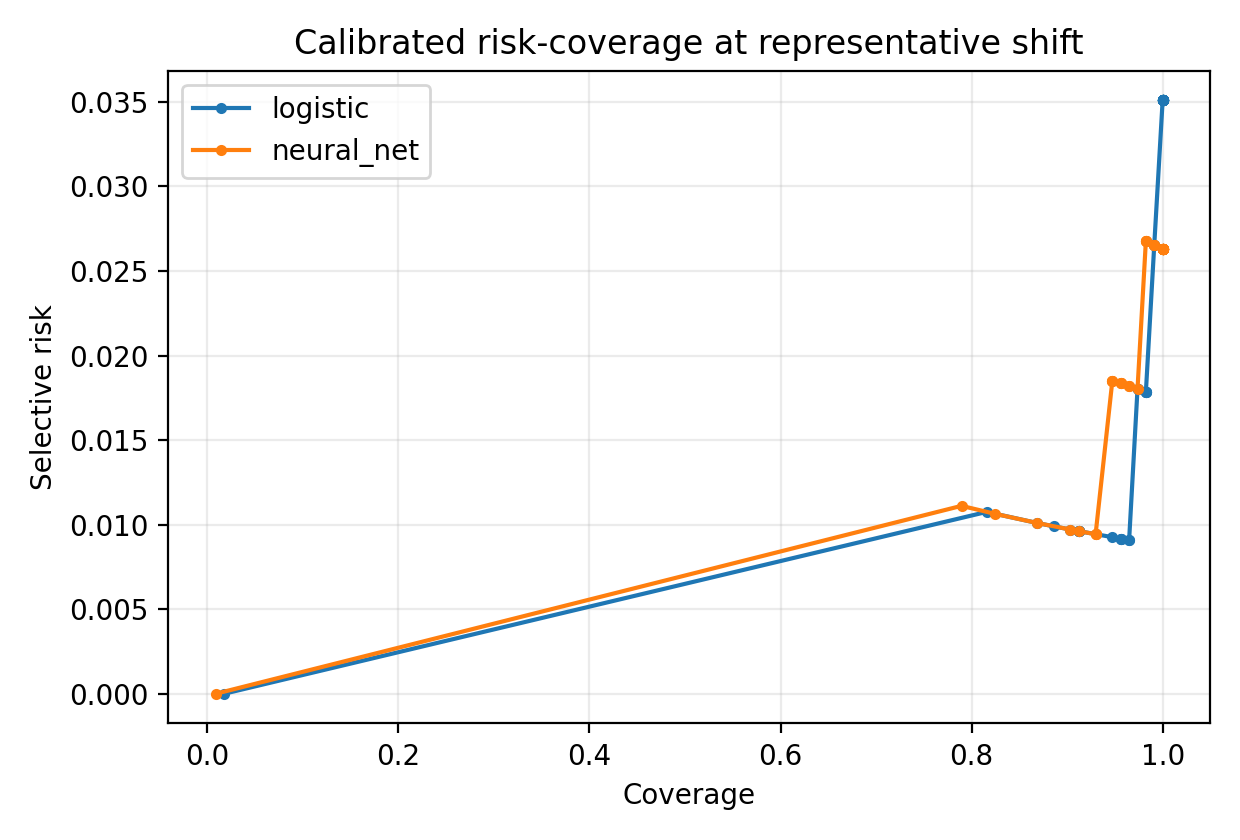

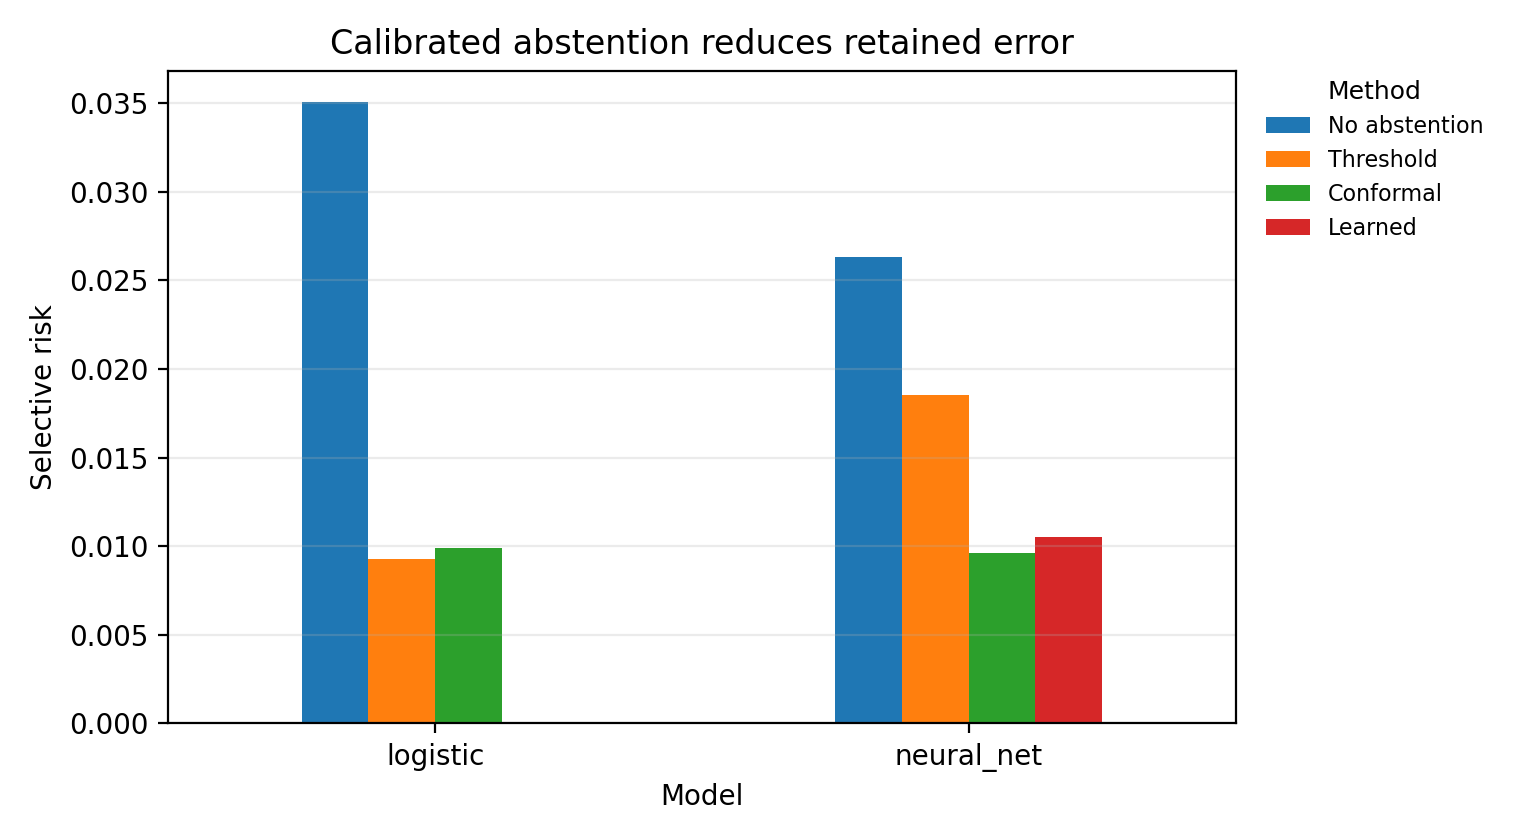

In [7]:
calibrated_abstention = abstention_summary[
    abstention_summary["probability_source"].eq("calibrated")
]
display(calibrated_abstention.round(4))
display(abstention_summary.round(4))
display(Image(filename=str(FIGURE_DIR / "risk_coverage.png")))
display(Image(filename=str(FIGURE_DIR / "abstention_risk.png")))

# Discussion

## What We Learned

The biggest lesson is that high clean accuracy is not enough evidence of reliability. Logistic regression looks excellent in distribution, but even a modest matched shift changes its calibration and increases class-sensitive error. The neural network has slightly better clean ECE but worse clean accuracy, and its log loss worsens under stronger shifts. This is a useful reminder that different metrics answer different questions: accuracy measures decisions, ECE measures confidence alignment, and log loss punishes confident mistakes.

We also learned that abstention should be evaluated with coverage and should consume calibrated uncertainty estimates when calibration is part of the method. A lower error rate is not meaningful if the model abstains on almost everything. In our experiments, calibrated threshold and conformal abstention reduced selective risk while keeping roughly 89-95% coverage, which is a practically meaningful tradeoff. Learned abstention reduced risk too, but its shifted coverage was lower than its calibration target, which is exactly the kind of failure mode that distribution-shift evaluation is meant to reveal.

With two more weeks, the next step would be a larger or more realistic external-shift dataset. The synthetic matched shift is useful because it gives controlled comparisons, but a real hospital-to-hospital or scanner-to-scanner shift would be a stronger test of whether these reliability tools transfer beyond the toy setting.

# Reproducibility

The final artifacts in this notebook were generated with:

```bash
python scripts/run_final_experiment.py
python scripts/build_final_report_notebook.py
python -m pytest tests/test_metrics_and_abstention.py
```

The reusable implementation lives in `src/evaluation/experiment_pipeline.py`, `src/evaluation/classification_metrics.py`, `src/abstention/conformal.py`, and `src/abstention/learned.py`.

# References

- Wolberg, W. H., Street, W. N., and Mangasarian, O. L. Breast Cancer Wisconsin diagnostic dataset.
- Guo, C., Pleiss, G., Sun, Y., and Weinberger, K. Q. (2017). On Calibration of Modern Neural Networks.
- Geifman, Y. and El-Yaniv, R. (2017). Selective Classification for Deep Neural Networks.
- Vovk, V., Gammerman, A., and Shafer, G. (2005). Algorithmic Learning in a Random World.